# 🦋 **Bootcamp Data Analytics 2026 - Correlação e Regressão**  



<img src = 'https://github.com/squad-ada-lovelace/Desafio_04-Correlacao_e_Regressao/blob/main/Assets/Desafio.png?raw=true'>



---



## **Squad Ada Lovelace** 💜

<img src = 'https://github.com/squad-ada-lovelace/Desafio_04-Correlacao_e_Regressao/blob/main/Assets/Squad.png?raw=true'>

## **Programação**

<img src = 'https://github.com/squad-ada-lovelace/Desafio_04-Correlacao_e_Regressao/blob/main/Assets/Sumario.png?raw=true'>

## **Organização**

<img src = 'https://github.com/squad-ada-lovelace/Desafio_04-Correlacao_e_Regressao/blob/2578951176d88aa2ff34f3e23694cdeebc58aa7e/Assets/Organiza%C3%A7%C3%A3o.png?raw=true'>



---



## **Desafio 4: Venda de Veículos Usados**

<img src = 'https://github.com/squad-ada-lovelace/Desafio_04-Correlacao_e_Regressao/blob/main/Assets/Contexto.png?raw=true'>

**Base de Dados:** desafio_carros_usados.csv
* **`id:`** Identificador único do veículo
* **`make:`** Marca do carro (ex: Ford, Toyota)
* **`model:`** Modelo do carro
* **`year:`** Ano de fabricação
* **`price:`** Preço de venda do carro
* **`mileage:`** Quilometragem (km rodados)
* **`engine_size:`** Tamanho do motor (em litros)
* **`fuel_type:`** Tipo de combustível (gasolina, diesel, elétrico)
* **`transmission:`** Tipo de transmissão (manual, automática)
* **`doors:`** Número de portas
* **`color:`** Cor do carro
* **`tax:`** Taxa anual de imposto veicular
* **`mpg:`** Milhas por Galão (indicador de eficiência de combustível)
* **`sold_date:`** Data de venda do veículo



---



### **Imports e definições de variáveis**

In [ ]:
import pandas as pd
import numpy as np

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Testes estatísticos e machine learning
import scipy.stats as stats
import statsmodels.api as sm

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/squad-ada-lovelace/Desafio_04-Correlacao_e_Regressao/refs/heads/main/carros_usados.csv")
df.head()

,id,make,model,year,price,mileage,engine_size,fuel_type,transmission,doors,color,tax,mpg,sold_date
0,1,Volkswagen,Model B,2022,23859,94811,3.6,Diesel,Manual,2,Grey,288,39.2,2023-10-11
1,2,Chevrolet,Model A,2008,16953,128028,4.9,Diesel,Manual,5,Red,339,15.3,2021-04-22
2,3,BMW,Model B,2006,12332,49178,4.1,Diesel,Automatic,4,Red,458,37.2,2020-05-04
3,4,Chevrolet,Model B,2018,18475,42821,2.7,Hybrid,Manual,5,Silver,486,43.7,2021-06-20
4,5,Chevrolet,Model C,2017,12129,192799,2.8,Gasoline,Manual,4,Silver,295,19.1,2021-12-06


In [ ]:
colunas_numericas = ["year", "price", "mileage", "engine_size", "doors", "tax", "mpg"]



---



### **Análise exploratória dos dados**

* **Colunas:** 14
* **Linhas:** 1000
* **Tipos de variáveis:** int, string e float
* **Dados nulos:** 0
* **Dados duplicados:** 0
* **Dados que precisam de tratamento:** `sold_date` está em formato de string, e não de data.

In [ ]:
# Verificação de dados nulos, nomes de colunas e tipos de variáveis

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            1000 non-null   int64  
 1   make          1000 non-null   object 
 2   model         1000 non-null   object 
 3   year          1000 non-null   int64  
 4   price         1000 non-null   int64  
 5   mileage       1000 non-null   int64  
 6   engine_size   1000 non-null   float64
 7   fuel_type     1000 non-null   object 
 8   transmission  1000 non-null   object 
 9   doors         1000 non-null   int64  
 10  color         1000 non-null   object 
 11  tax           1000 non-null   int64  
 12  mpg           1000 non-null   float64
 13  sold_date     1000 non-null   object 
dtypes: float64(2), int64(6), object(6)
memory usage: 109.5+ KB


In [ ]:
# Conversão da variável sold_date para o tipo datetime

df["sold_date"] = pd.to_datetime(df["sold_date"])

In [ ]:
# Verificação de dados duplicados

df.duplicated().sum()

np.int64(0)

In [ ]:
# Estatísticas gerais dos dados

df.describe()

,id,year,price,mileage,engine_size,doors,tax,mpg,sold_date
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000
mean,500.500000,2013.555000,20524.900000,106665.076000,2.978400,3.549000,294.58000,29.980800,2022-01-13 21:48:57.599999744
min,1.000000,2005.000000,3000.000000,10203.000000,1.000000,2.000000,100.00000,10.100000,2020-01-02 00:00:00
25%,250.750000,2009.000000,15836.250000,57933.500000,2.000000,3.000000,188.00000,20.300000,2021-01-28 00:00:00
50%,500.500000,2014.000000,20622.500000,105654.000000,3.000000,4.000000,295.50000,29.600000,2022-01-23 12:00:00
75%,750.250000,2018.000000,25378.250000,157543.250000,4.000000,5.000000,392.25000,40.400000,2023-01-10 06:00:00
max,1000.000000,2022.000000,42823.000000,199651.000000,5.000000,5.000000,499.00000,50.000000,2023-12-28 00:00:00
std,288.819436,5.236066,7241.830627,55414.820244,1.151494,1.100368,114.83892,11.721802,NaN


In [ ]:
# Quantidade de valores únicos por variável numérica

df[colunas_numericas].nunique().sort_values(ascending=False)

,0
mileage,995
price,976
mpg,366
tax,360
engine_size,41
year,18
doors,4




---



### **1 - Análise de Correlação**

* Calcule a correlação entre as variáveis numéricas e o preço do carro (price).
* Quais variáveis estão mais correlacionadas com o preço?
* Quais estão menos correlacionadas?

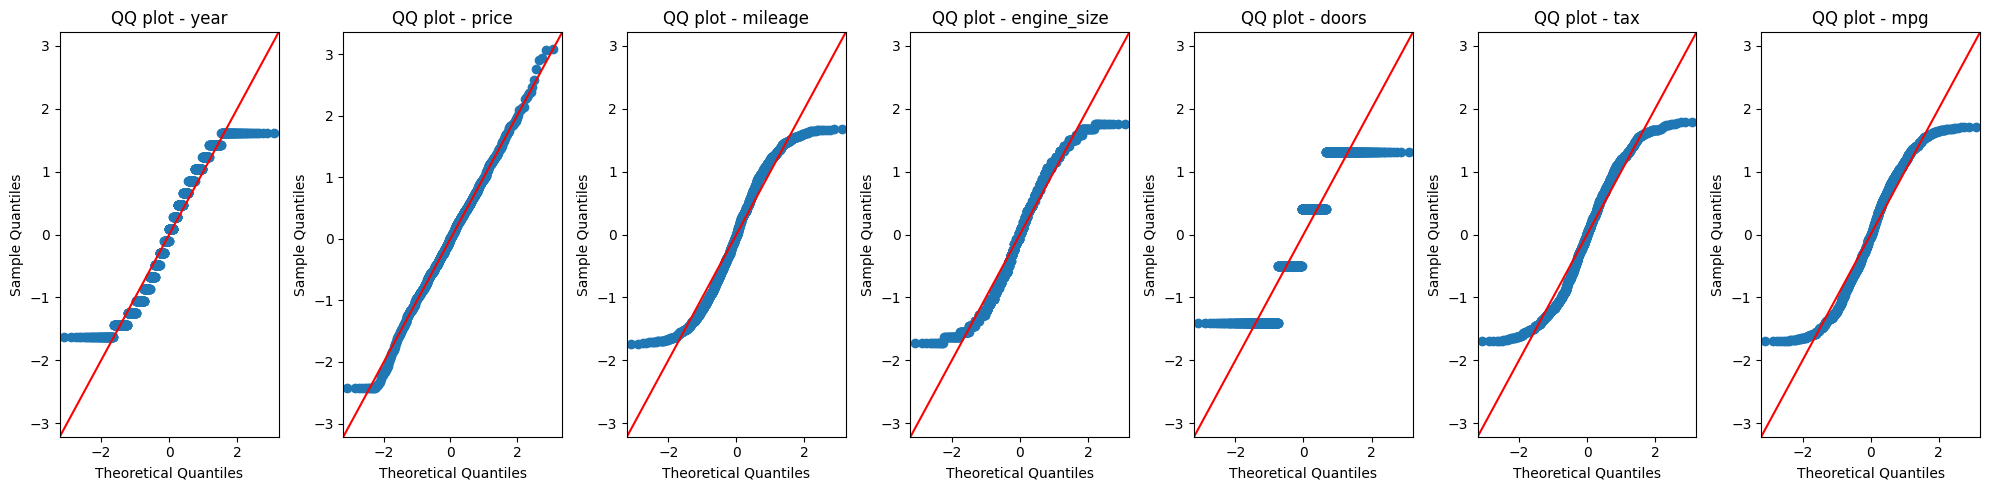

In [ ]:
# Verificação da normalidade dos dados

fig, axes = plt.subplots(1, 7, figsize=(20, 5))

for i,coluna  in enumerate(colunas_numericas):
  sm.qqplot(df[coluna], line="45", fit=True, ax=axes[i])
  axes[i].set_title(f"QQ plot - {coluna}")

plt.tight_layout()

plt.show()

In [ ]:
# Matriz de correlação para dados que não apresentam distribuição normal, ordenados pela distância do valor com 0

matriz_correlacao = df.corr(numeric_only=True, method="spearman")[["price"]].drop(["price", "id"]).sort_values(by="price", ascending=False, key=abs)
matriz_correlacao

,price
year,-0.037657
doors,0.033927
engine_size,-0.015377
mpg,-0.011421
mileage,0.009419
tax,-0.001198


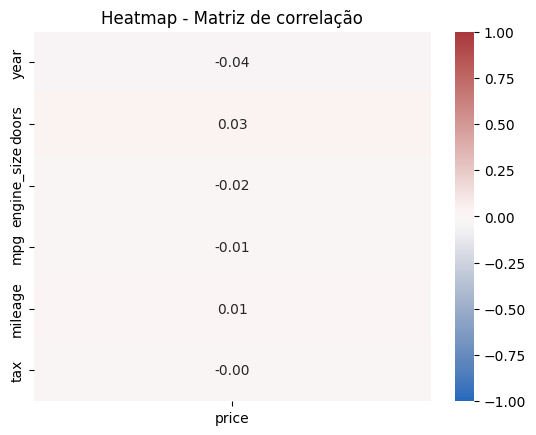

In [ ]:
# Heatmap da matriz de correlação

sns.heatmap(matriz_correlacao, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1)
plt.title("Heatmap - Matriz de correlação")
plt.show()

* **Variáveis que estão `mais` correlacionadas com o preço:**
  * As variáveis com os maiores coeficientes de correlação em relação ao preço são `year` (-0.04) e `doors` (0.03).
  * Porém, como os valores são próximos a 0 não é possível afirmar que a correlação é forte, mas sim que há **ausência de correlação**.
* **Variáveis que estão `menos` correlacionadas com o preço:**
  * As menores correlações entre o preço e as variáveis numéricas são `tax` (0.00) e  `mileage` (0.01).



---



### **2 - Análise das 5 Variáveis Mais Correlacionadas**

Para as cinco variáveis com maior correlação com o preço:
1. Plote histograma e boxplot de cada variável.
2. Plote o scatterplot (gráfico de dispersão), com price no eixo Y e a
variável no eixo X.
3. Faça uma regressão linear simples, utilizando cada variável como
preditora (X) e o preço como resposta (Y). Interprete os coeficientes e
o R2.

#### **Histogramas**

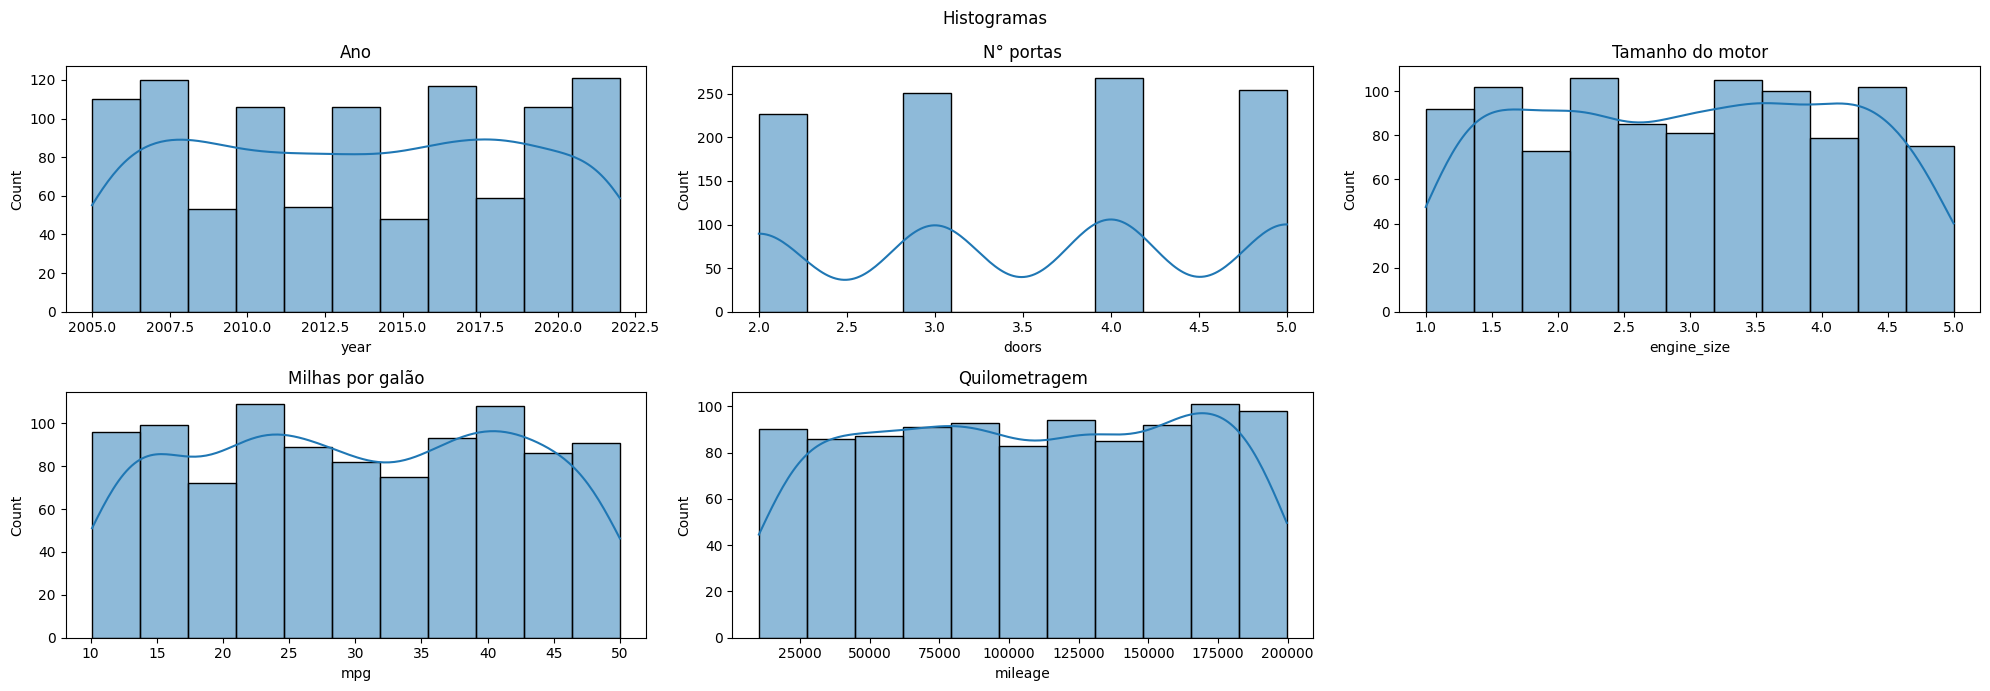

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 7))

# year
sns.histplot(x="year", data=df, kde = True, ax=axes[0, 0])
axes[0, 0].set_title("Ano")

# doors
sns.histplot(x="doors", data=df, kde = True,ax=axes[0, 1])
axes[0, 1].set_title("N° portas")

# engine_size
sns.histplot(x="engine_size", data=df, kde = True, ax=axes[0, 2])
axes[0, 2].set_title("Tamanho do motor")

# mpg
sns.histplot(x="mpg", data=df, kde = True, ax=axes[1, 0])
axes[1, 0].set_title("Milhas por galão")

# mileage
sns.histplot(x="mileage", data=df, kde = True, ax=axes[1, 1])
axes[1, 1].set_title("Quilometragem")

plt.suptitle("Histogramas")
fig.delaxes(axes[1, 2])
plt.tight_layout()
plt.show()

#### **Box plots**

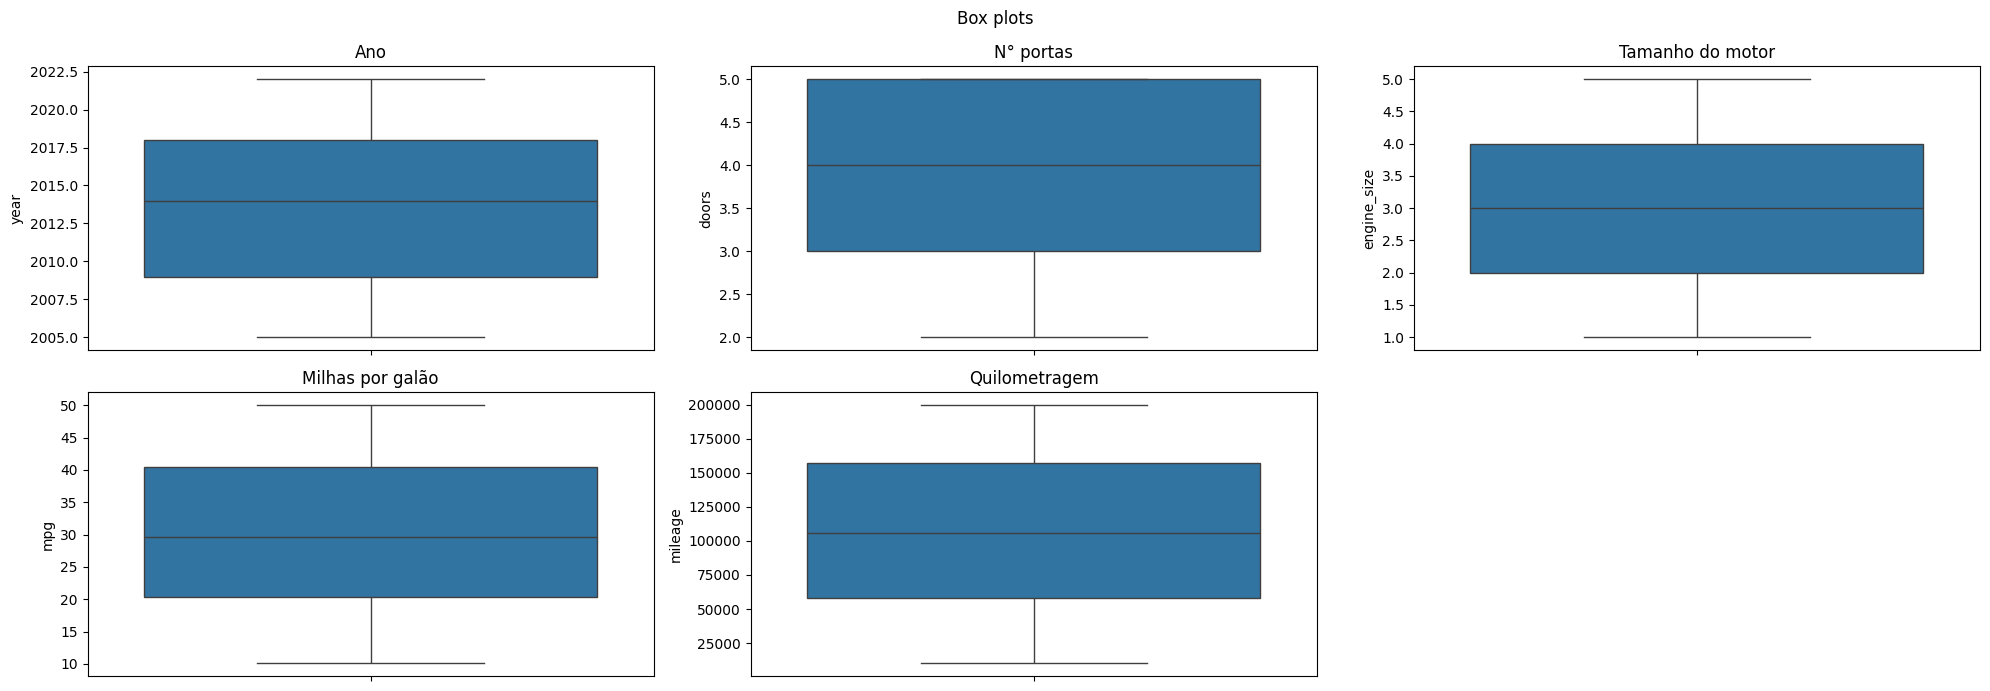

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 7))

# year
sns.boxplot(y="year", data=df, ax=axes[0, 0])
axes[0, 0].set_title("Ano")

# doors
sns.boxplot(y="doors", data=df, ax=axes[0, 1])
axes[0, 1].set_title("N° portas")

# engine_size
sns.boxplot(y="engine_size", data=df, ax=axes[0, 2])
axes[0, 2].set_title("Tamanho do motor")

# mpg
sns.boxplot(y="mpg", data=df, ax=axes[1, 0])
axes[1, 0].set_title("Milhas por galão")

# mileage
sns.boxplot(y="mileage", data=df, ax=axes[1, 1])
axes[1, 1].set_title("Quilometragem")

plt.suptitle("Box plots")
fig.delaxes(axes[1, 2])
plt.tight_layout()
plt.show()

#### **Scatter plots**

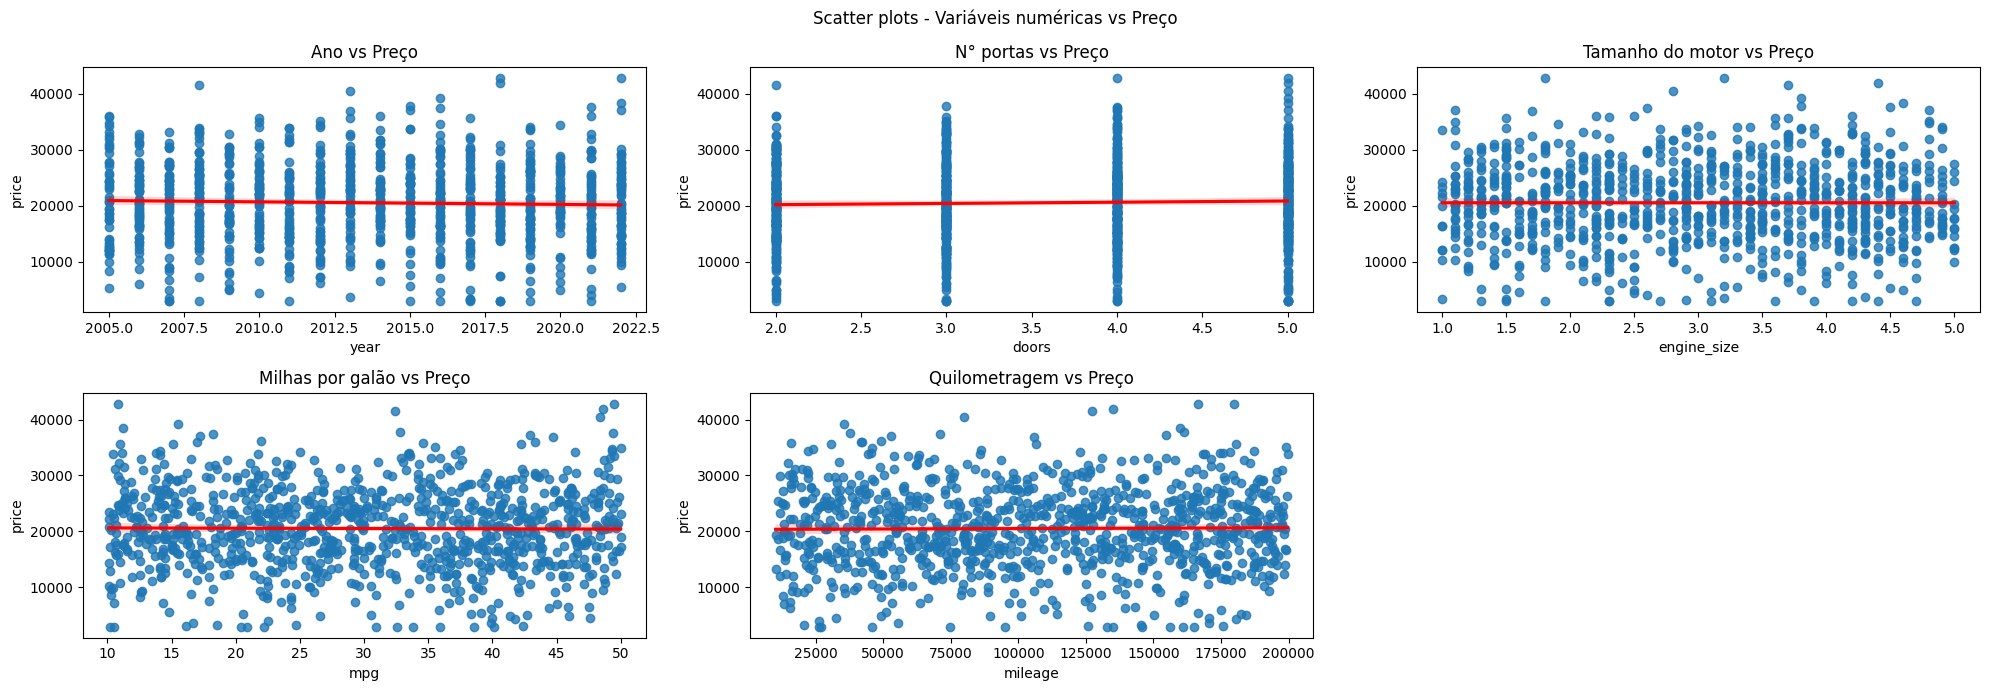

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 7))

# year
sns.regplot(x="year", y="price", data=df, line_kws={"color": "red"}, ax=axes[0, 0])
axes[0, 0].set_title("Ano vs Preço")

# doors
sns.regplot(x="doors", y="price", data=df, line_kws={"color": "red"},ax=axes[0, 1])
axes[0, 1].set_title("N° portas vs Preço")

# engine_size
sns.regplot(x="engine_size", y="price", data=df, line_kws={"color": "red"}, ax=axes[0, 2])
axes[0, 2].set_title("Tamanho do motor vs Preço")

# mpg
sns.regplot(x="mpg", y="price", data=df, line_kws={"color": "red"}, ax=axes[1, 0])
axes[1, 0].set_title("Milhas por galão vs Preço")

# mileage
sns.regplot(x="mileage", y="price", data=df, line_kws={"color": "red"}, ax=axes[1, 1])
axes[1, 1].set_title("Quilometragem vs Preço")

plt.suptitle("Scatter plots - Variáveis numéricas vs Preço")
fig.delaxes(axes[1, 2])
plt.tight_layout()
plt.show()

#### **Regressão linear simples**

##### Análise de outliers

In [ ]:
colunas_numericas.remove("tax")

for coluna in colunas_numericas:
  Q1 = df[coluna].quantile(0.25)
  Q3 = df[coluna].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  df_outliers = df[(df[coluna] < lower_bound) | (df[coluna] > upper_bound)].copy()

  print(f"--- {coluna} ---")
  if df_outliers.shape[0] > 0:
    print(f"Qtd outilers: {df_outliers.shape[0]}")
    print(f"Total linhas antes da remoção de outliers: {df.shape[0]}")
    df = df.drop(df_outliers.index)
    print(f"Total linhas após a remoção de outliers: {df.shape[0]}\n")
  else:
    print("Ausência de outliers\n")

--- year ---
Ausência de outliers

--- price ---
Qtd outilers: 5
Total linhas antes da remoção de outliers: 1000
Total linhas após a remoção de outliers: 995

--- mileage ---
Ausência de outliers

--- engine_size ---
Ausência de outliers

--- doors ---
Ausência de outliers

--- mpg ---
Ausência de outliers



##### Year

In [ ]:
x = sm.add_constant(df["year"])
y = df["price"]

model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.656
Date:                Wed, 29 Jul 2026   Prob (F-statistic):              0.198
Time:                        18:15:27   Log-Likelihood:                -10234.
No. Observations:                 995   AIC:                         2.047e+04
Df Residuals:                     993   BIC:                         2.048e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.318e+05   8.66e+04      1.523      0.1

###### Análise de resíduos

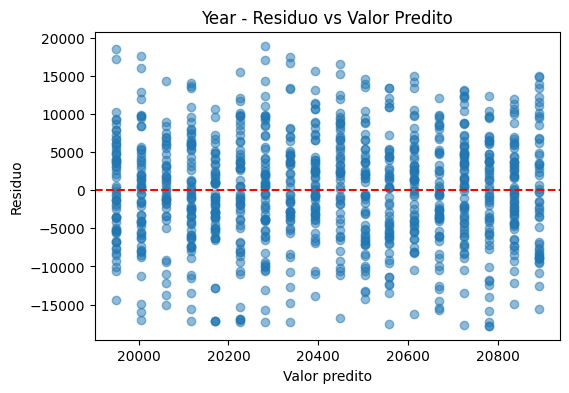

In [ ]:
residuo = model.resid
predito = model.fittedvalues

plt.figure(figsize=(6, 4))
plt.scatter(predito, residuo, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Year - Residuo vs Valor Predito')
plt.xlabel('Valor predito')
plt.ylabel('Residuo')

plt.show()

* **Modelo:** `price` = 1.318e+05 - 55.3230 * `year`
  * Indica que a cada ano o preço de um carro diminuiria em média $55.32
* **R²:** 0.002
  * Resultado próximo a 0 ➝ o modelo de forma geral não consegue explicar os dados (apenas 0.2%)
* **P-valor:** 0.198
  * Resultado > 0.05 ➝ variável `year` não tem relevância estatística para explicar `price`
* **Análise de resíduos:** resíduos não estão distribuídos de forma aleatória em torno de zero ➝ padrão de colunas
  * Indica que o modelo não está capturando corretamente a estrutura dos dados

##### Doors

In [ ]:
x = sm.add_constant(df["doors"])
y = df["price"]

model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.6293
Date:                Wed, 29 Jul 2026   Prob (F-statistic):              0.428
Time:                        18:15:27   Log-Likelihood:                -10234.
No. Observations:                 995   AIC:                         2.047e+04
Df Residuals:                     993   BIC:                         2.048e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.984e+04    760.609     26.086      0.0

###### Análise de resíduos

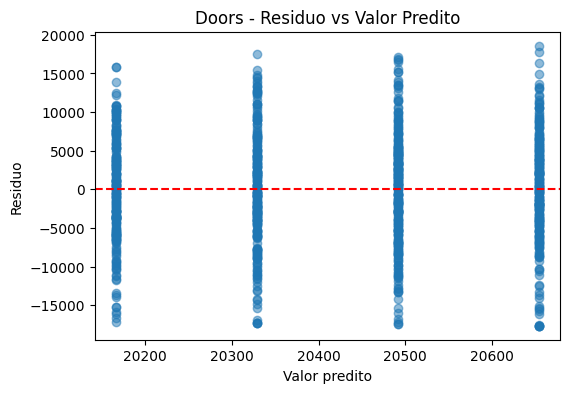

In [ ]:
residuo = model.resid
predito = model.fittedvalues

plt.figure(figsize=(6, 4))
plt.scatter(predito, residuo, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Doors - Residuo vs Valor Predito')
plt.xlabel('Valor predito')
plt.ylabel('Residuo')

plt.show()

* **Modelo:** `price` = 1.984e+04 + 162.5445 * `doors`
  * Indica que a cada porta adicionada faria o preço aumentar em média $162.54
* **R²:** 0.001
  * Resultado próximo a 0 ➝ o modelo de forma geral **não consegue explicar os dados** (apenas 0.1%)
* **P-valor:** 0.428
  * Resultado > 0.05 ➝ variável `doors` **não tem relevância estatística** para explicar `price`
* **Análise de resíduos:** resíduos não estão distribuídos de forma aleatória em torno de zero ➝ padrão de colunas
  * Indica que o modelo não está capturando corretamente a estrutura dos dados

##### Engine size

In [ ]:
x = sm.add_constant(df["engine_size"])
y = df["price"]

model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                  0.007435
Date:                Wed, 29 Jul 2026   Prob (F-statistic):              0.931
Time:                        18:15:28   Log-Likelihood:                -10235.
No. Observations:                 995   AIC:                         2.047e+04
Df Residuals:                     993   BIC:                         2.048e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        2.047e+04    623.946     32.804      

###### Análise de resíduos

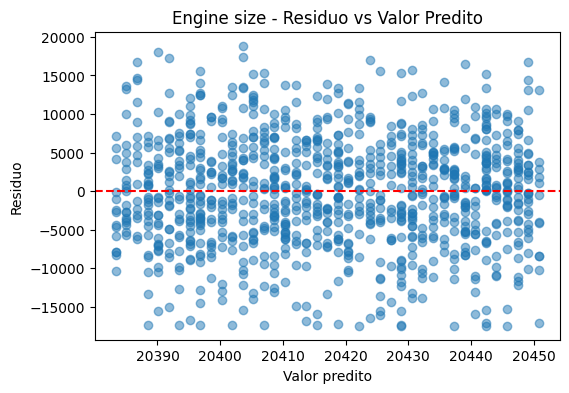

In [ ]:
residuo = model.resid
predito = model.fittedvalues

plt.figure(figsize=(6, 4))
plt.scatter(predito, residuo, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Engine size - Residuo vs Valor Predito')
plt.xlabel('Valor predito')
plt.ylabel('Residuo')

plt.show()

* **Modelo:** `price` = 2.047e+04 - 16.8517 * `engine_size`
  * Indica que a medida que o tamanho do motor aumenta, o preço diminuiria em média $16.85 ➝ não faz sentido
* **R²:** 0.000
  * Resultado igual a 0 ➝ o modelo **não consegue explicar os dados**
* **P-valor:** 0.931
  * Resultado > 0.05 ➝ variável `engine_size` **não tem relevância estatística** para explicar `price`
* **Análise de resíduos:** resíduos não estão distribuídos de forma aleatória em torno de zero ➝ padrão de colunas
  * Indica que o modelo não está capturando corretamente a estrutura dos dados

##### MPG

In [ ]:
x = sm.add_constant(df["mpg"])
y = df["price"]

model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.3389
Date:                Wed, 29 Jul 2026   Prob (F-statistic):              0.561
Time:                        18:15:28   Log-Likelihood:                -10235.
No. Observations:                 995   AIC:                         2.047e+04
Df Residuals:                     993   BIC:                         2.048e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.075e+04    619.280     33.512      0.0

###### Análise de resíduos

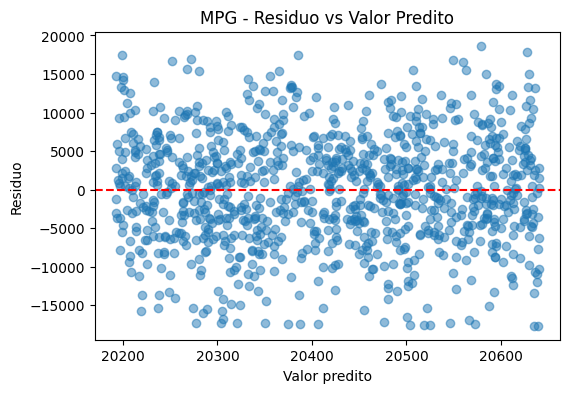

In [ ]:
residuo = model.resid
predito = model.fittedvalues

plt.figure(figsize=(6, 4))
plt.scatter(predito, residuo, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('MPG - Residuo vs Valor Predito')
plt.xlabel('Valor predito')
plt.ylabel('Residuo')

plt.show()

* **Modelo:** `price` = 2.075e+04 - 11.2165 * `mpg`
  * Indica que a a cada milha por galão a mais (maior eficiência de combustível), o preço diminuiria em média $11.22
* **R²:** 0.000
  * Resultado igual a 0 ➝ o modelo **não consegue explicar os dados**
* **P-valor:** 0.561
  * Resultado > 0.05 ➝ variável `mpg` **não tem relevância estatística** para explicar `price`
* **Análise de resíduos:** resíduos estão distribuídos de forma aleatória em torno de zero
  * É possível que seja devido a grande quantidade de valores únicos em `mpg` (366)
  * Não significa necessariamente que o modelo está adequado aos dados

##### Mileage

In [ ]:
x = sm.add_constant(df["mileage"])
y = df["price"]

model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                  0.006070
Date:                Wed, 29 Jul 2026   Prob (F-statistic):              0.938
Time:                        18:15:28   Log-Likelihood:                -10235.
No. Observations:                 995   AIC:                         2.047e+04
Df Residuals:                     993   BIC:                         2.048e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.038e+04    487.747     41.792      0.0

###### Análise de resíduos

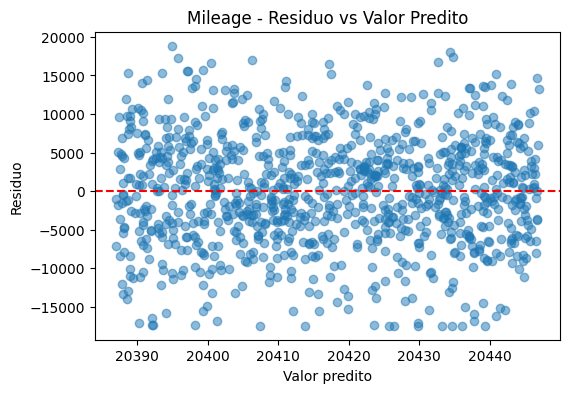

In [ ]:
residuo = model.resid
predito = model.fittedvalues

plt.figure(figsize=(6, 4))
plt.scatter(predito, residuo, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Mileage - Residuo vs Valor Predito')
plt.xlabel('Valor predito')
plt.ylabel('Residuo')

plt.show()

* **Modelo:** `price` = 2.038e+04 + 0.0003 * `mileage`
  * Indica que a a medida que a quilometragem aumenta, o preço aumentaria em média $0.0003 ➝ não faz sentido
* **R²:** 0.000
  * Resultado igual a 0 ➝ o modelo **não consegue explicar os dados**
* **P-valor:** 0.938
  * Resultado > 0.05 ➝ variável `mileage` **não tem relevância estatística** para explicar `price`
* **Análise de resíduos:** resíduos estão distribuídos de forma aleatória em torno de zero
  * É possível que seja devido a grande quantidade de valores únicos em `mileage` (990)
  * Não significa necessariamente que o modelo está adequado aos dados



---



## **Conclusões**

<img src = 'https://github.com/squad-ada-lovelace/Desafio_04-Correlacao_e_Regressao/blob/main/Assets/Conclus%C3%B5es.png?raw=true'>




## **Recomendações**

<img src = 'https://github.com/squad-ada-lovelace/Desafio_04-Correlacao_e_Regressao/blob/main/Assets/Recomenda%C3%A7%C3%B5es.png?raw=true'>



---



## **Facilidades e desafios**

<img src = 'https://github.com/squad-ada-lovelace/Desafio_04-Correlacao_e_Regressao/blob/main/Assets/Desafios.png?raw=true'>
